In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from tqdm import tqdm

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
DATA_ROOT = Path("/home/l.bazdyrev/.cache/kagglehub/datasets/balraj98/massachusetts-roads-dataset/versions/1")

train_img_dir = DATA_ROOT / "tiff" / "train"
train_mask_dir = DATA_ROOT / "tiff" / "train_labels"

val_img_dir = DATA_ROOT / "tiff" / "val"
val_mask_dir = DATA_ROOT / "tiff" / "val_labels"

test_img_dir = DATA_ROOT / "tiff" / "test"
test_mask_dir = DATA_ROOT / "tiff" / "test_labels"

print("train:", len(list(train_img_dir.glob("*"))), len(list(train_mask_dir.glob("*"))))
print("val  :", len(list(val_img_dir.glob("*"))), len(list(val_mask_dir.glob("*"))))
print("test :", len(list(test_img_dir.glob("*"))), len(list(test_mask_dir.glob("*"))))

train: 1108 1108
val  : 14 14
test : 49 49


In [4]:
TILE_SIZE = 512
STRIDE = 256

BATCH_SIZE = 6
NUM_WORKERS = 4

LR = 3e-4
NUM_EPOCHS = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [5]:
def generate_positions(size, tile_size, stride):
    positions = list(range(0, size - tile_size + 1, stride))
    if not positions:
        return [0]
    if positions[-1] != size - tile_size:
        positions.append(size - tile_size)
    return positions

In [6]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2(),
])

In [7]:
class RoadsWindowDataset(Dataset):
    def __init__(self, images_dir, masks_dir, tile_size=512, stride=256, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.tile_size = tile_size
        self.stride = stride
        self.transform = transform

        self.image_paths = sorted(self.images_dir.glob("*"))
        self.mask_paths = sorted(self.masks_dir.glob("*"))

        assert len(self.image_paths) == len(self.mask_paths), "images/masks count mismatch"

        self.samples = []

        for img_path, mask_path in zip(self.image_paths, self.mask_paths):
            mask = tiff.imread(str(mask_path))

            if mask.ndim == 3:
                mask = mask[..., 0]

            h, w = mask.shape[:2]
            ys = generate_positions(h, self.tile_size, self.stride)
            xs = generate_positions(w, self.tile_size, self.stride)

            for y in ys:
                for x in xs:
                    self.samples.append((img_path, mask_path, x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.samples[idx]

        image = tiff.imread(str(img_path))
        mask = tiff.imread(str(mask_path))

        if image.ndim == 3 and image.shape[0] in [3, 4] and image.shape[-1] not in [3, 4]:
            image = np.transpose(image, (1, 2, 0))

        if mask.ndim == 3:
            mask = mask[..., 0]

        image = image[y:y + self.tile_size, x:x + self.tile_size]
        mask = mask[y:y + self.tile_size, x:x + self.tile_size]

        image = image.astype(np.uint8)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.unsqueeze(0)

In [8]:
train_dataset = RoadsWindowDataset(
    images_dir=train_img_dir,
    masks_dir=train_mask_dir,
    tile_size=512,
    stride=256,
    transform=train_transform
)

val_dataset = RoadsWindowDataset(
    images_dir=val_img_dir,
    masks_dir=val_mask_dir,
    tile_size=512,
    stride=256,
    transform=val_transform
)

test_dataset = RoadsWindowDataset(
    images_dir=test_img_dir,
    masks_dir=test_mask_dir,
    tile_size=512,
    stride=256,
    transform=val_transform
)

print("train windows:", len(train_dataset))
print("val windows  :", len(val_dataset))
print("test windows :", len(test_dataset))

train windows: 27700
val windows  : 350
test windows : 1225


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

torch.Size([6, 3, 512, 512]) torch.Size([6, 1, 512, 512])


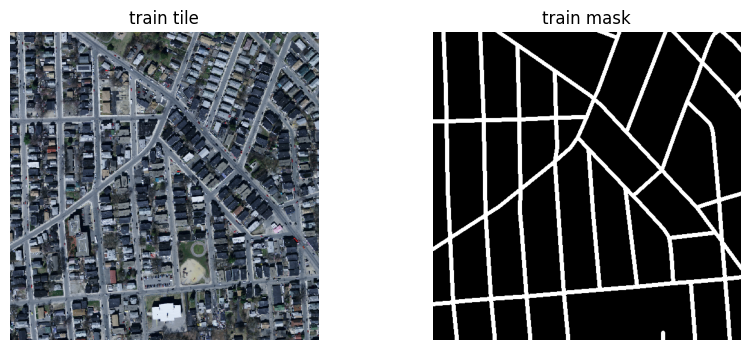

In [10]:
images, masks = next(iter(train_loader))
print(images.shape, masks.shape)

img = images[0].permute(1, 2, 0).cpu().numpy()
msk = masks[0, 0].cpu().numpy()

img = (img - img.min()) / (img.max() - img.min() + 1e-8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("train tile")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(msk, cmap="gray")
plt.title("train mask")
plt.axis("off")

plt.show()

In [11]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(DEVICE)

In [12]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    dice = num / den
    return 1 - dice.mean()

def total_loss(logits, targets):
    return 0.3 * bce_loss(logits, targets) + 0.7 * dice_loss(logits, targets)

def iou_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    total = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice = (2 * intersection + eps) / (total + eps)
    return dice.mean().item()

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

In [14]:
writer = SummaryWriter("runs/roads_unet")

In [15]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss_value = 0.0
    total_iou = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = total_loss(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss_value += loss.item()

        with torch.no_grad():
            total_iou += iou_score(logits, masks)
            total_dice += dice_score(logits, masks)

    return (
        total_loss_value / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )

@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    total_loss_value = 0.0
    total_iou = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="val", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = total_loss(logits, masks)

        total_loss_value += loss.item()
        total_iou += iou_score(logits, masks)
        total_dice += dice_score(logits, masks)

    return (
        total_loss_value / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )

In [16]:
@torch.no_grad()
def log_predictions_to_tensorboard(model, loader, device, writer, epoch, num_images=3):
    model.eval()

    images, masks = next(iter(loader))
    images = images.to(device)

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

    for i in range(min(num_images, images.size(0))):
        img = images[i].cpu()
        true_mask = masks[i].cpu()
        pred_mask = preds[i].cpu()

        writer.add_image(f"Image/{i}", img, epoch)
        writer.add_image(f"TrueMask/{i}", true_mask, epoch)
        writer.add_image(f"PredMask/{i}", pred_mask, epoch)

In [17]:
best_iou = 0.0
history = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss, train_iou, train_dice = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_iou, val_dice = validate_one_epoch(model, val_loader, DEVICE)

    scheduler.step(val_iou)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("IoU/train", train_iou, epoch)
    writer.add_scalar("Dice/train", train_dice, epoch)

    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("IoU/val", val_iou, epoch)
    writer.add_scalar("Dice/val", val_dice, epoch)

    log_predictions_to_tensorboard(model, val_loader, DEVICE, writer, epoch, num_images=3)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_iou": train_iou,
        "train_dice": train_dice,
        "val_loss": val_loss,
        "val_iou": val_iou,
        "val_dice": val_dice,
    })

    print(
        f"epoch {epoch+1:02d}: "
        f"train_loss={train_loss:.4f} "
        f"train_iou={train_iou:.4f} "
        f"train_dice={train_dice:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_iou={val_iou:.4f} "
        f"val_dice={val_dice:.4f}"
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_roads_unet_03bce07dice.pth")
        print("saved best model")

writer.close()

history_df = pd.DataFrame(history)
history_df


Epoch 1/40


epoch 01: train_loss=0.3858 train_iou=0.4664 train_dice=0.5810 val_loss=0.2542 val_iou=0.5691 val_dice=0.7116
saved best model

Epoch 2/40


epoch 02: train_loss=0.3520 train_iou=0.5067 train_dice=0.6181 val_loss=0.2592 val_iou=0.5627 val_dice=0.7063

Epoch 3/40


epoch 03: train_loss=0.3447 train_iou=0.5146 train_dice=0.6249 val_loss=0.2404 val_iou=0.5938 val_dice=0.7325
saved best model

Epoch 4/40


epoch 04: train_loss=0.3401 train_iou=0.5212 train_dice=0.6309 val_loss=0.2314 val_iou=0.5990 val_dice=0.7371
saved best model

Epoch 5/40


...

epoch 37: train_loss=0.2968 train_iou=0.5845 train_dice=0.6873 val_loss=0.2169 val_iou=0.6256 val_dice=0.7591

Epoch 38/40


epoch 38: train_loss=0.2964 train_iou=0.5871 train_dice=0.6899 val_loss=0.2171 val_iou=0.6248 val_dice=0.7589

Epoch 39/40


epoch 39: train_loss=0.2955 train_iou=0.5888 train_dice=0.6912 val_loss=0.2167 val_iou=0.6253 val_dice=0.7590

Epoch 40/40


epoch 40: train_loss=0.2948 train_iou=0.5925 train_dice=0.6949 val_loss=0.2167 val_iou=0.6258 val_dice=0.7592


,epoch,train_loss,train_iou,train_dice,val_loss,val_iou,val_dice
0,1,0.385795,0.466352,0.580997,0.254240,0.569096,0.711591
1,2,0.351997,0.506720,0.618074,0.259242,0.562745,0.706331
2,3,0.344711,0.514611,0.624922,0.240351,0.593812,0.732521
3,4,0.340135,0.521164,0.630854,0.231372,0.599042,0.737120
4,5,0.335733,0.527004,0.636154,0.229040,0.604817,0.740673
5,6,0.333050,0.531064,0.639706,0.228529,0.604968,0.742104
6,7,0.331107,0.533737,0.642282,0.222374,0.616279,0.751813
7,8,0.329284,0.537523,0.645594,0.236867,0.599590,0.737455
8,9,0.328295,0.539097,0.646885,0.229306,0.608283,0.743213
9,10,0.326362,0.541096,0.648762,0.235861,0.599563,0.736073


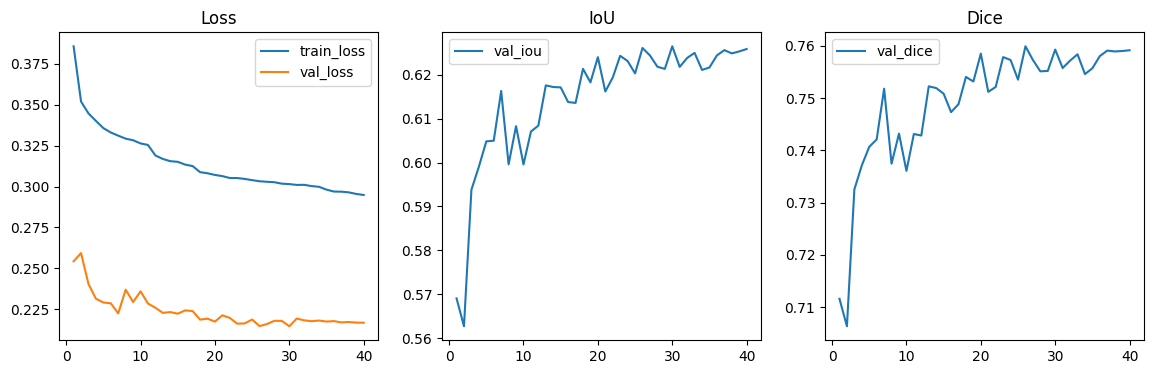

In [18]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["val_iou"], label="val_iou")
plt.legend()
plt.title("IoU")

plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["val_dice"], label="val_dice")
plt.legend()
plt.title("Dice")

plt.show()

In [ ]:
best_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

best_model.load_state_dict(torch.load("best_roads_unet.pth", map_location=DEVICE))
best_model = best_model.to(DEVICE)
best_model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
def predict_full_image(
    model,
    image_path,
    transform,
    device,
    tile_size=512,
    stride=256,
    threshold=0.5
):
    model.eval()

    image = tiff.imread(str(image_path))

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    h, w = image.shape[:2]

    prob_map = np.zeros((h, w), dtype=np.float32)

    count_map = np.zeros((h, w), dtype=np.float32)

    ys = generate_positions(h, tile_size, stride)
    xs = generate_positions(w, tile_size, stride)

    with torch.no_grad():
        for y in ys:
            for x in xs:
                tile = image[y:y + tile_size, x:x + tile_size]

                transformed = transform(image=tile)
                tile_tensor = transformed["image"].unsqueeze(0).to(device)

                logits = model(tile_tensor)
                probs = torch.sigmoid(logits).squeeze().cpu().numpy()

                prob_map[y:y + tile_size, x:x + tile_size] += probs
                count_map[y:y + tile_size, x:x + tile_size] += 1.0

    prob_map /= np.maximum(count_map, 1e-8)
    pred_mask = (prob_map > threshold).astype(np.uint8)

    return image, prob_map, pred_mask

In [21]:
def show_full_prediction(image, prob_map, pred_mask, gt_mask=None, figsize=(18, 6)):
    cols = 4 if gt_mask is not None else 3
    plt.figure(figsize=figsize)

    plt.subplot(1, cols, 1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, cols, 2)
    plt.imshow(prob_map, cmap="gray")
    plt.title("Probability map")
    plt.axis("off")

    plt.subplot(1, cols, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted mask")
    plt.axis("off")

    if gt_mask is not None:
        plt.subplot(1, cols, 4)
        plt.imshow(gt_mask, cmap="gray")
        plt.title("Ground truth")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def read_full_mask(mask_path):
    mask = tiff.imread(str(mask_path))

    if mask.ndim == 3:
        mask = mask[..., 0]

    mask = (mask > 0).astype(np.uint8)
    return mask

In [23]:
def compute_iou_and_dice(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(np.float32)
    gt = gt_mask.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)

    return iou, dice

In [24]:
test_loss, test_iou, test_dice = validate_one_epoch(best_model, test_loader, DEVICE)

print(f"test_loss = {test_loss:.4f}")
print(f"test_iou  = {test_iou:.4f}")
print(f"test_dice = {test_dice:.4f}")

test_loss = 0.2325
test_iou  = 0.6402
test_dice = 0.7602


In [25]:
@torch.no_grad()
def show_predictions(model, loader, device, n=3):
    model.eval()

    images, masks = next(iter(loader))
    images = images.to(device)

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

    for i in range(min(n, images.size(0))):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        true_mask = masks[i, 0].cpu().numpy()
        pred_mask = preds[i, 0].numpy()

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Pred mask")
        plt.axis("off")

        plt.show()

In [26]:
test_loss, test_iou, test_dice = validate_one_epoch(model, test_loader, DEVICE)

print(f"test_loss = {test_loss:.4f}")
print(f"test_iou  = {test_iou:.4f}")
print(f"test_dice = {test_dice:.4f}")

test_loss = 0.2356
test_iou  = 0.6341
test_dice = 0.7533


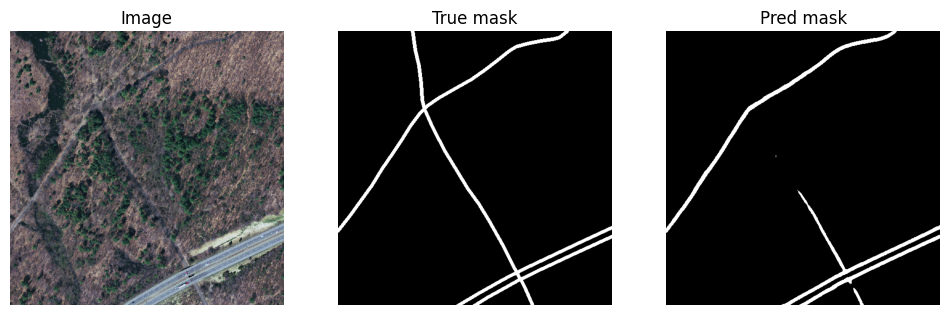

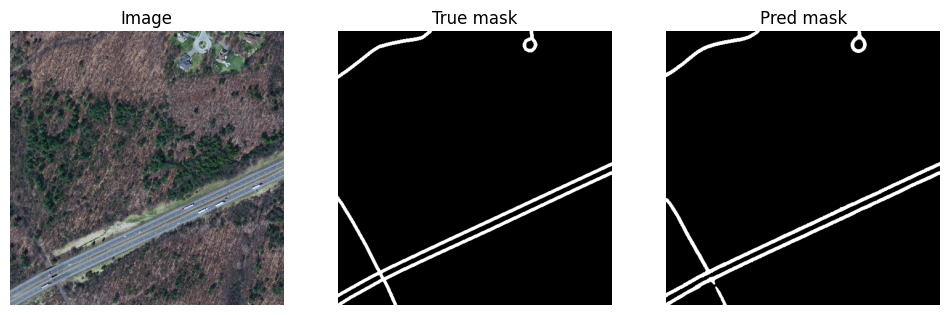

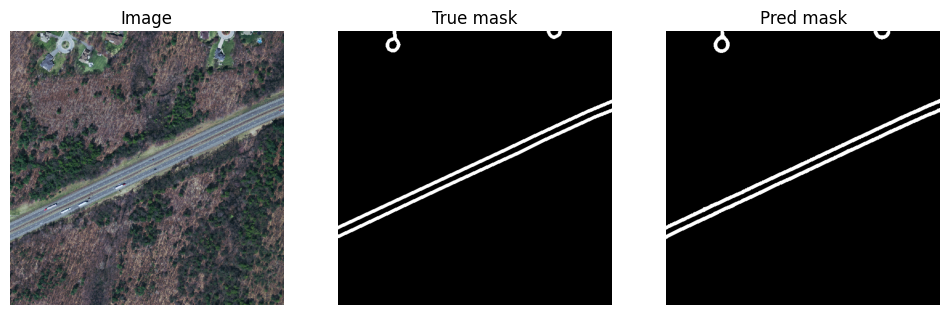

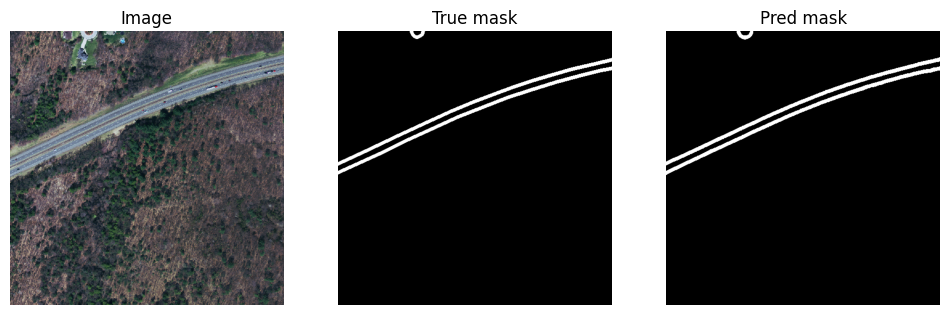

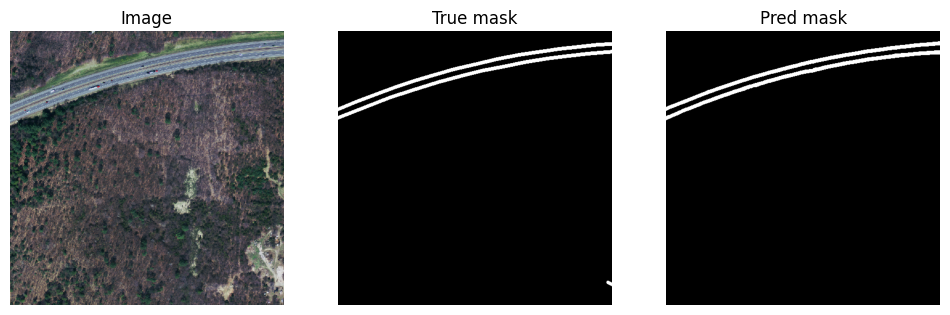

In [27]:
show_predictions(best_model, test_loader, DEVICE, n=5)

Found test images: 49
Found test masks: 49
Image: 10828720_15.tiff
Mask:  10828720_15.tif


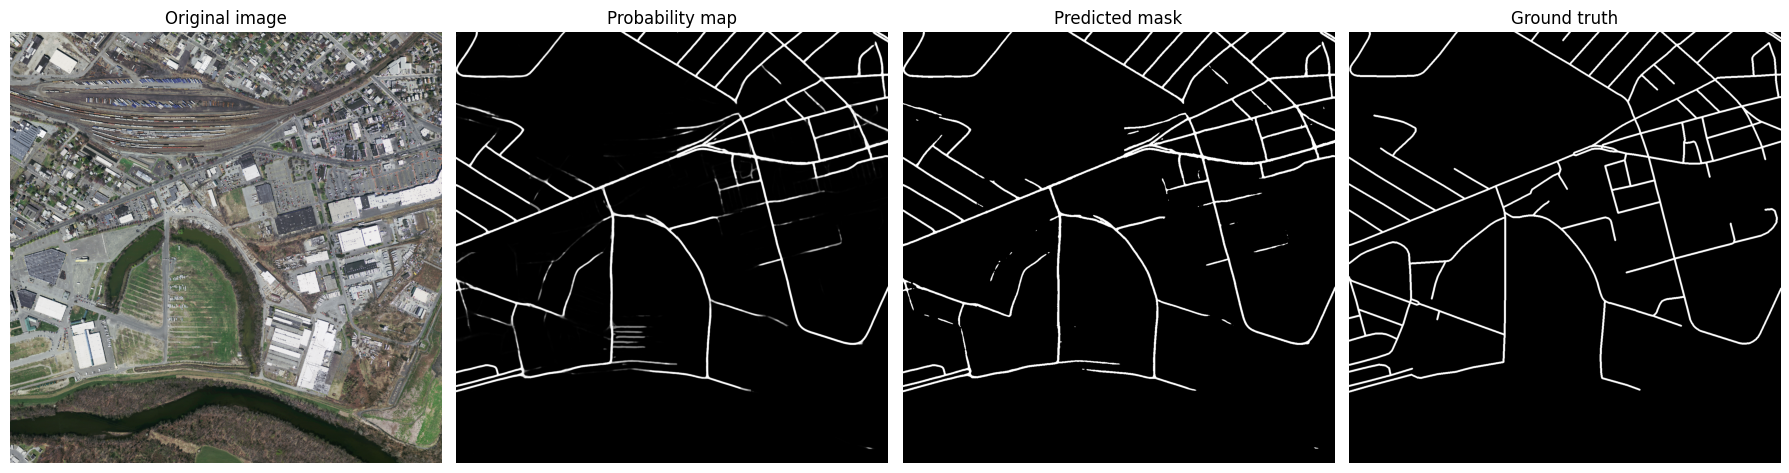

Full-image IoU:  0.5225
Full-image Dice: 0.6864


In [28]:
test_image_paths = sorted(Path(test_img_dir).glob("*.tiff"))
test_mask_paths = sorted(Path(test_mask_dir).glob("*.tif"))

print("Found test images:", len(test_image_paths))
print("Found test masks:", len(test_mask_paths))

mask_map = {p.stem: p for p in test_mask_paths}

image_path = test_image_paths[1]
image_stem = image_path.stem

if image_stem not in mask_map:
    raise ValueError(f"Mask not found for image: {image_stem}")

mask_path = mask_map[image_stem]

print("Image:", image_path.name)
print("Mask: ", mask_path.name)

image, prob_map, pred_mask = predict_full_image(
    model=best_model,
    image_path=image_path,
    transform=val_transform,
    device=DEVICE,
    tile_size=TILE_SIZE,
    stride=STRIDE,
    threshold=best_threshold if "best_threshold" in globals() else 0.5
)

gt_mask = read_full_mask(mask_path)

show_full_prediction(image, prob_map, pred_mask, gt_mask)

iou, dice = compute_iou_and_dice(pred_mask, gt_mask)
print(f"Full-image IoU:  {iou:.4f}")
print(f"Full-image Dice: {dice:.4f}")

In [29]:
print(model.decoder.blocks[0])

UnetDecoderBlock(
  (conv1): Conv2dReLU(
    (0): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (attention1): Attention(
    (attention): Identity()
  )
  (conv2): Conv2dReLU(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (attention2): Attention(
    (attention): Identity()
  )
)


In [30]:
import inspect
print(inspect.getsource(model.decoder.blocks[0].forward))

    def forward(
        self,
        feature_map: torch.Tensor,
        target_height: int,
        target_width: int,
        skip_connection: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        feature_map = F.interpolate(
            feature_map,
            size=(target_height, target_width),
            mode=self.interpolation_mode,
        )
        if skip_connection is not None:
            feature_map = torch.cat([feature_map, skip_connection], dim=1)
            feature_map = self.attention1(feature_map)
        feature_map = self.conv1(feature_map)
        feature_map = self.conv2(feature_map)
        feature_map = self.attention2(feature_map)
        return feature_map



In [31]:
best_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

best_model.load_state_dict(torch.load("best_roads_unet.pth", map_location=DEVICE))
best_model = best_model.to(DEVICE)
best_model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

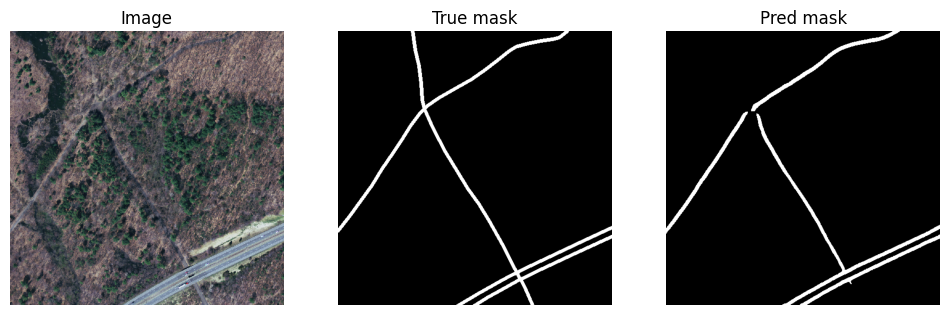

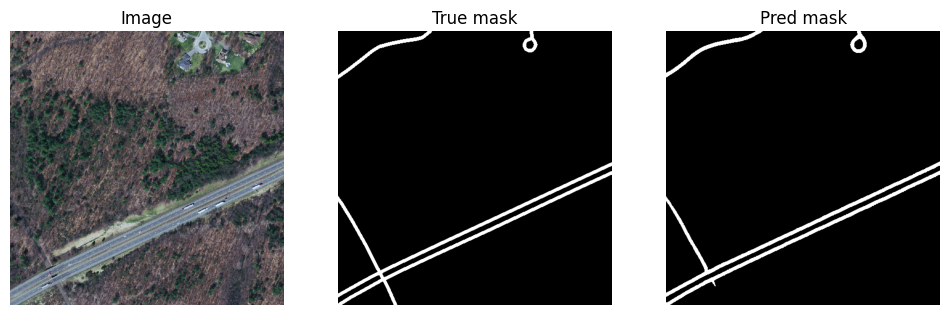

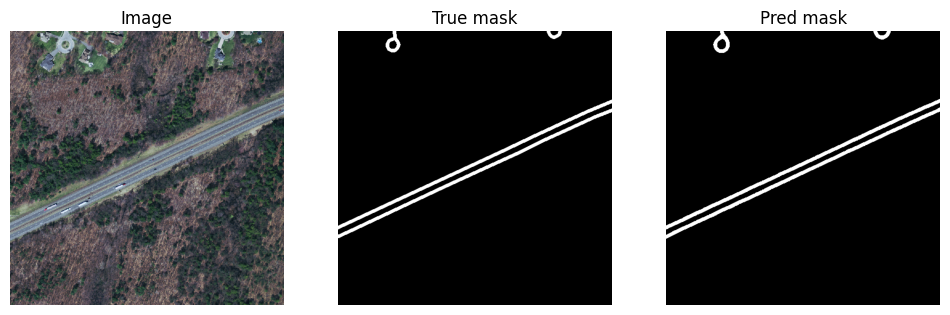

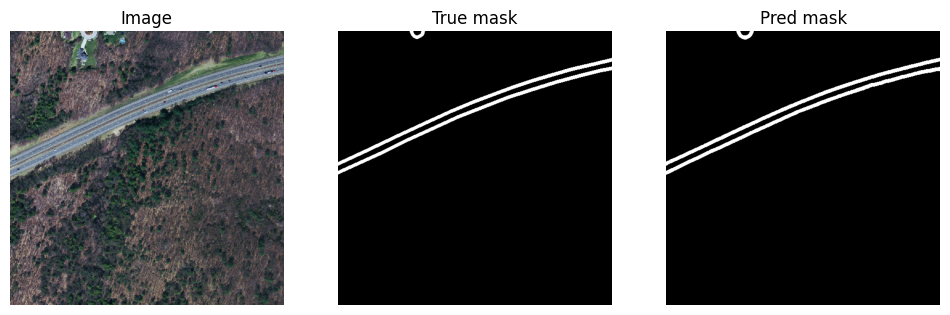

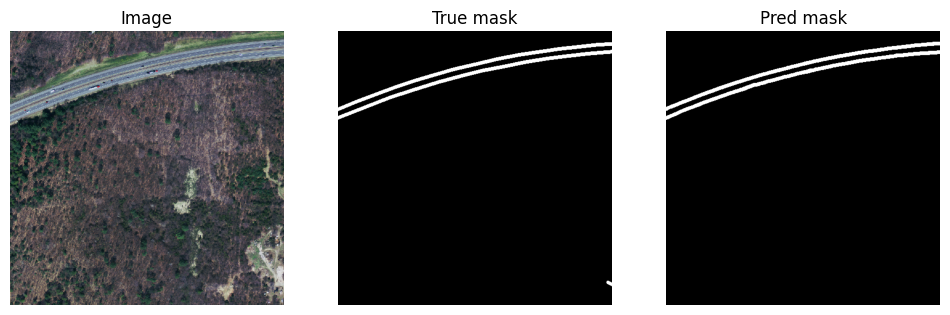

In [32]:
show_predictions(best_model, test_loader, DEVICE, n=5)

In [33]:
test_loss, test_iou, test_dice = validate_one_epoch(best_model, test_loader, DEVICE)

print(f"test_loss = {test_loss:.4f}")
print(f"test_iou  = {test_iou:.4f}")
print(f"test_dice = {test_dice:.4f}")

test_loss = 0.2354
test_iou  = 0.6344
test_dice = 0.7535


Found test images: 49
Found test masks: 49
Image: 10828720_15.tiff
Mask:  10828720_15.tif


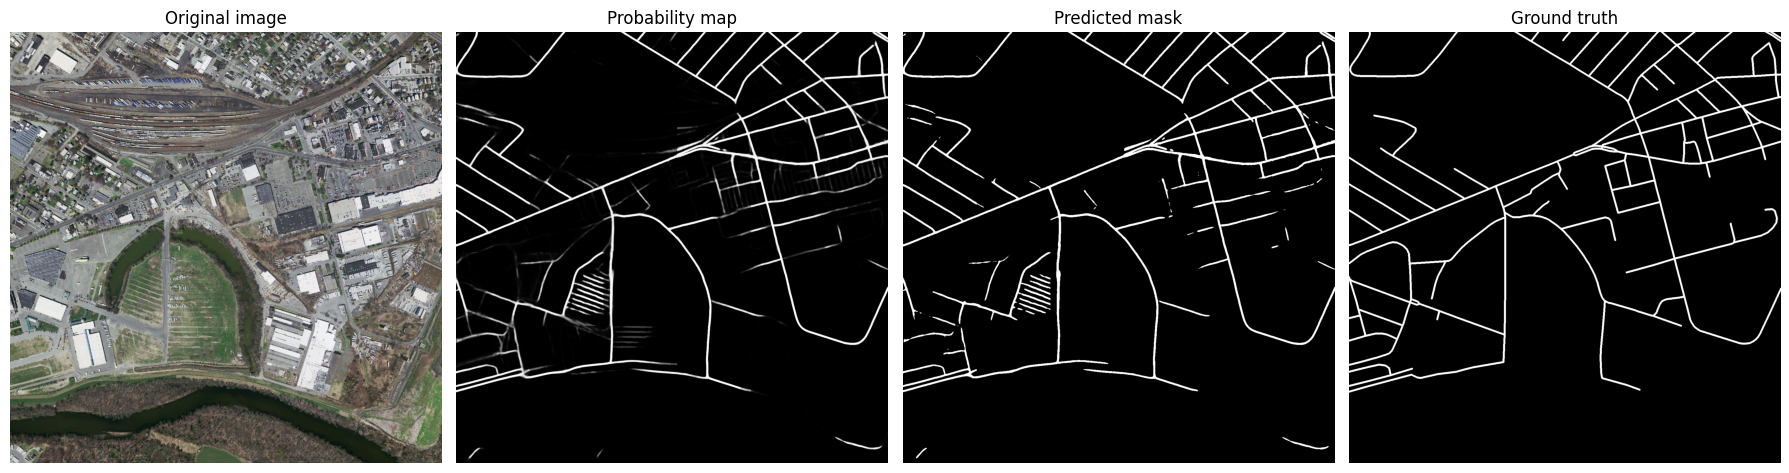

Full-image IoU:  0.5056
Full-image Dice: 0.6716


In [34]:
test_image_paths = sorted(Path(test_img_dir).glob("*.tiff"))
test_mask_paths = sorted(Path(test_mask_dir).glob("*.tif"))

print("Found test images:", len(test_image_paths))
print("Found test masks:", len(test_mask_paths))

mask_map = {p.stem: p for p in test_mask_paths}

image_path = test_image_paths[1]
image_stem = image_path.stem

if image_stem not in mask_map:
    raise ValueError(f"Mask not found for image: {image_stem}")

mask_path = mask_map[image_stem]

print("Image:", image_path.name)
print("Mask: ", mask_path.name)

image, prob_map, pred_mask = predict_full_image(
    model=best_model,
    image_path=image_path,
    transform=val_transform,
    device=DEVICE,
    tile_size=TILE_SIZE,
    stride=STRIDE,
    threshold=best_threshold if "best_threshold" in globals() else 0.5
)

gt_mask = read_full_mask(mask_path)

show_full_prediction(image, prob_map, pred_mask, gt_mask)

iou, dice = compute_iou_and_dice(pred_mask, gt_mask)
print(f"Full-image IoU:  {iou:.4f}")
print(f"Full-image Dice: {dice:.4f}")